<a href="https://colab.research.google.com/github/Jish-k/XAI-LAB4/blob/main/Lab3_SHAP_on_tabular_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install libraries

In [1]:
pip install shap xgboost

In [2]:
pip install plotly

## Import libraries

In [3]:
import matplotlib.pylab as pl
import numpy as np
import xgboost
from sklearn.model_selection import train_test_split
import shap

# print the JS visualization code to the notebook
shap.initjs()

## Import dataset

In [4]:
X, y = shap.datasets.adult()
X_display, y_display = shap.datasets.adult(display=True)

In [5]:
print(X_display)

        Age          Workclass  Education-Num       Marital Status  \
0      39.0          State-gov           13.0        Never-married   
1      50.0   Self-emp-not-inc           13.0   Married-civ-spouse   
2      38.0            Private            9.0             Divorced   
3      53.0            Private            7.0   Married-civ-spouse   
4      28.0            Private           13.0   Married-civ-spouse   
...     ...                ...            ...                  ...   
32556  27.0            Private           12.0   Married-civ-spouse   
32557  40.0            Private            9.0   Married-civ-spouse   
32558  58.0            Private            9.0              Widowed   
32559  22.0            Private            9.0        Never-married   
32560  52.0       Self-emp-inc            9.0   Married-civ-spouse   

               Occupation    Relationship    Race      Sex  Capital Gain  \
0            Adm-clerical   Not-in-family   White     Male        2174.0   
1      

In [6]:
print(y_display)

[False False False ... False False  True]


## Create test-train split

In [7]:
# create a train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
d_train = xgboost.DMatrix(X_train, label=y_train)
d_test = xgboost.DMatrix(X_test, label=y_test)

In [8]:
print(X.shape)

(32561, 12)


In [9]:
print(X_train)

        Age  Workclass  Education-Num  Marital Status  Occupation  \
12011  51.0          4           10.0               0           6   
23599  51.0          1           14.0               6          12   
23603  21.0          4           11.0               4           3   
6163   25.0          4           10.0               4          12   
14883  48.0          4           13.0               0           1   
...     ...        ...            ...             ...         ...   
5699   23.0          4            9.0               4          12   
10742  37.0          4            9.0               2           7   
16921  27.0          6            5.0               2           3   
25796  46.0          4           16.0               2          10   
28847  55.0          4           10.0               0          13   

       Relationship  Race  Sex  Capital Gain  Capital Loss  Hours per week  \
12011             0     4    0           0.0           0.0            40.0   
23599          

In [10]:
print(X_train.shape)

(26048, 12)


## Define parameters for xgboost

In [11]:
params = {
    "eta": 0.01,
    "objective": "binary:logistic",
    "subsample": 0.5,
    "base_score": np.mean(y_train),
    "eval_metric": "logloss",
}
model = xgboost.train(
    params,
    d_train,
    5000,
    evals=[(d_test, "test")],
    verbose_eval=100,
    early_stopping_rounds=20,
)

[0]	test-logloss:0.54666
[100]	test-logloss:0.36390
[200]	test-logloss:0.31754
[300]	test-logloss:0.30058
[400]	test-logloss:0.29155
[500]	test-logloss:0.28652
[600]	test-logloss:0.28343
[700]	test-logloss:0.28173
[800]	test-logloss:0.28058
[900]	test-logloss:0.27976
[1000]	test-logloss:0.27924
[1100]	test-logloss:0.27893
[1200]	test-logloss:0.27878
[1208]	test-logloss:0.27876


## Print accuracy

In [12]:
from sklearn.metrics import accuracy_score

# Make predictions
y_pred_prob = model.predict(d_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 87.53%


## SHAP explainer

In [13]:
# This takes 5-6 minutes since we are explaining over 30
#thousand samples in a model with over a thousand trees
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

## SHAP force plot
A SHAP force plot explains why a machine-learning model made one particular prediction

In [14]:
import plotly.io as pio

# Set the default renderer for Plotly to 'colab'
pio.renderers.default = 'colab'

# print the JS visualization code to the notebook
shap.initjs()  # Ensure this line is uncommented

shap.force_plot(explainer.expected_value, shap_values[50, :], X_display.iloc[50, :])


In [15]:
# Index of the sample you are interested in
sample_index = 49

# Get feature names
feature_names = X_display.columns

# Get SHAP values for that sample
shap_values_sample = shap_values[sample_index]

# Get the actual feature values for that sample
feature_values = X_display.iloc[sample_index]

# Print SHAP value for each feature
for name, value, shap_val in zip(feature_names, feature_values, shap_values_sample):
    if isinstance(value, (int, float)):  # If it's a number, format it
        val_str = f"{value:10.4f}"
    else:  # Otherwise just print the string
        val_str = f"{str(value):>10}"

    print(f"Feature: {name:20s} | Value: {val_str} | SHAP Value: {shap_val:+.4f}")


Feature: Age                  | Value:       29.0 | SHAP Value: -0.2337
Feature: Workclass            | Value:    Private | SHAP Value: +0.0045
Feature: Education-Num        | Value:       11.0 | SHAP Value: -0.0135
Feature: Marital Status       | Value:  Never-married | SHAP Value: -0.2437
Feature: Occupation           | Value:  Prof-specialty | SHAP Value: +0.3160
Feature: Relationship         | Value:  Not-in-family | SHAP Value: -1.0807
Feature: Race                 | Value:      White | SHAP Value: +0.0218
Feature: Sex                  | Value:       Male | SHAP Value: +0.1408
Feature: Capital Gain         | Value:        0.0 | SHAP Value: -0.1918
Feature: Capital Loss         | Value:        0.0 | SHAP Value: -0.0561
Feature: Hours per week       | Value:       43.0 | SHAP Value: +0.3015
Feature: Country              | Value:  United-States | SHAP Value: +0.0135


In [16]:
# Set the default renderer for Plotly to 'colab'
pio.renderers.default = 'colab'

# print the JS visualization code to the notebook
shap.initjs()  # Ensure this line is uncommented

shap.force_plot(
    explainer.expected_value, shap_values[:1000, :], X_display.iloc[:1000, :]
)

## SHAP summary plot
The purpose of shap.summary_plot(shap_values, X_display, plot_type="bar") is to provide a global explanation of your model by showing which features are most important overall across the dataset.

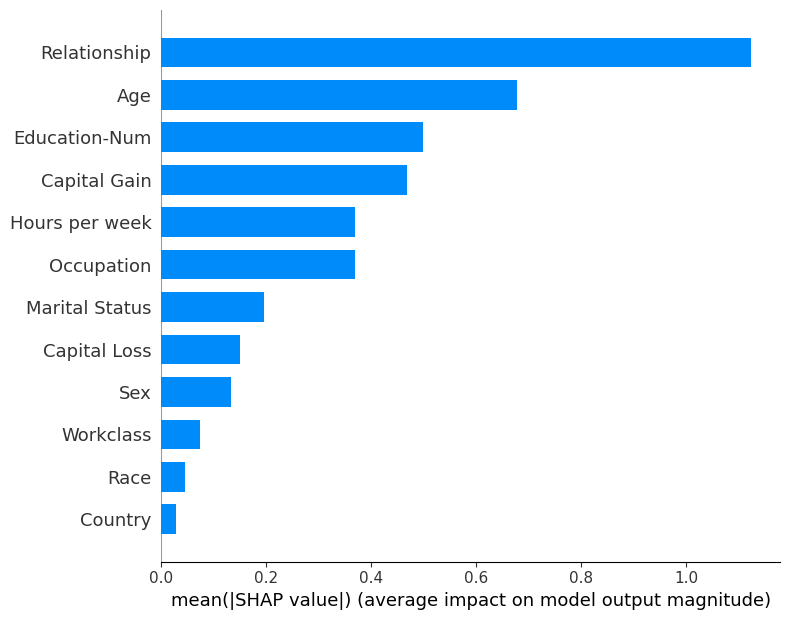

In [17]:
shap.summary_plot(shap_values, X_display, plot_type="bar")

## SHAP dependence plot
A SHAP dependence plot shows how the value of one feature affects the model prediction across many observations.

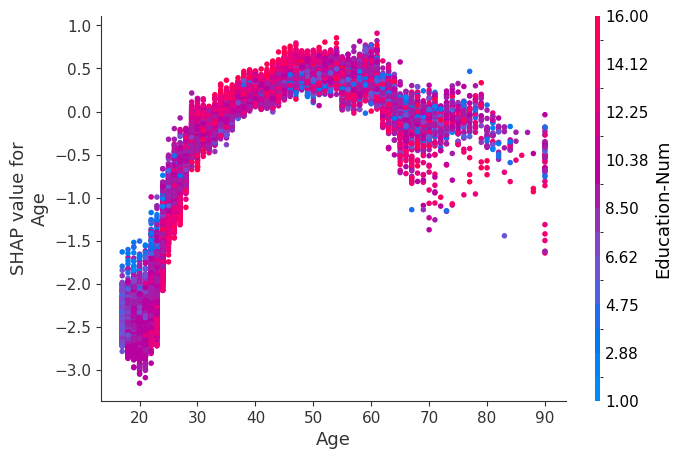

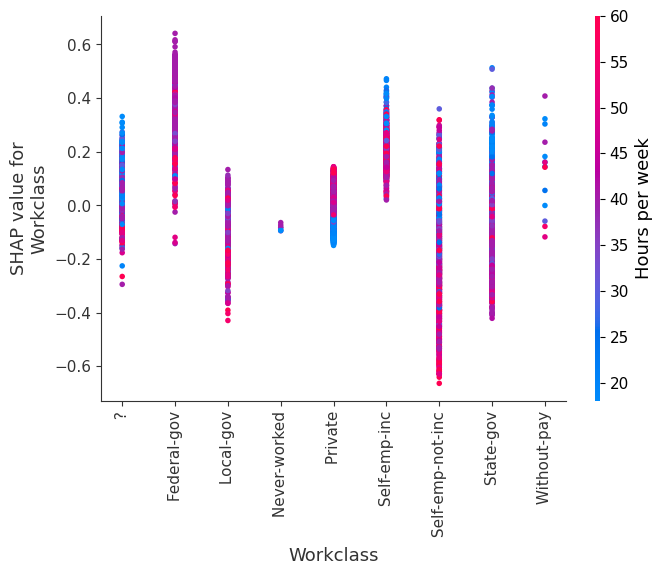

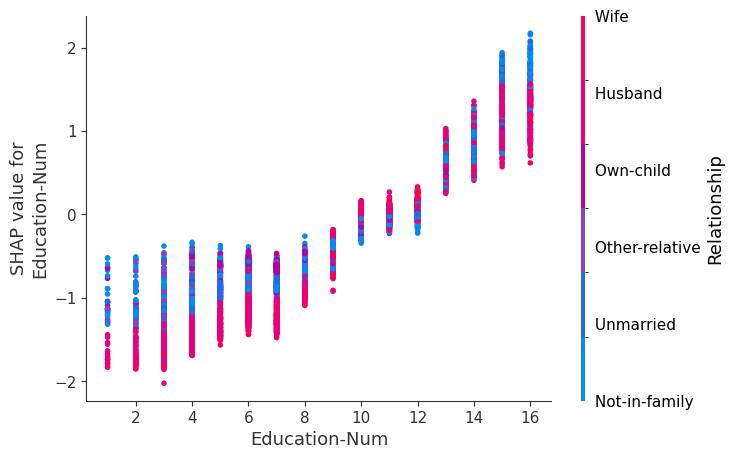

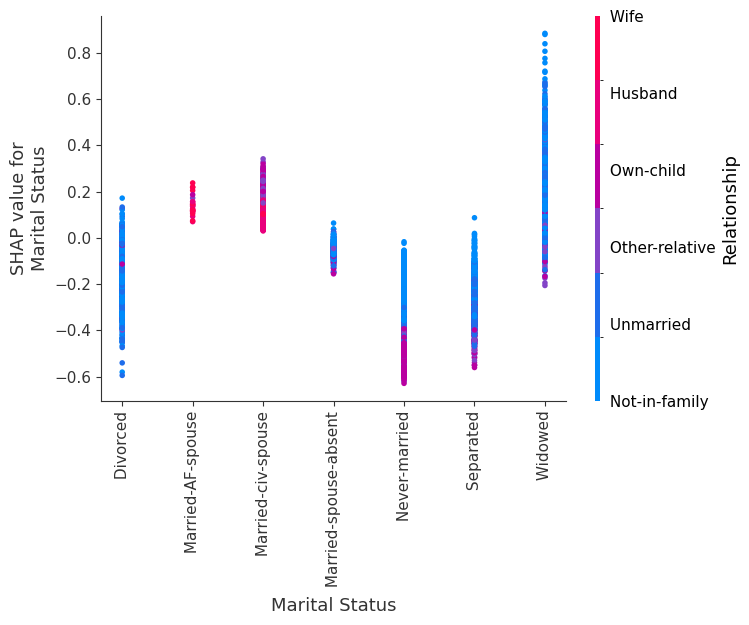

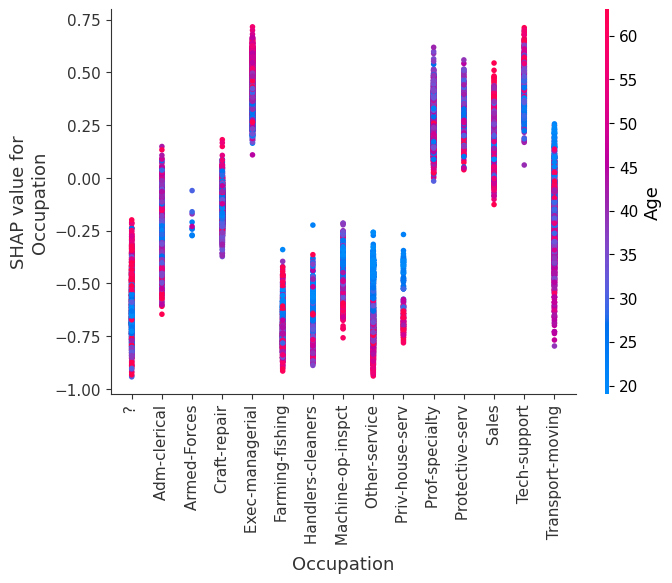

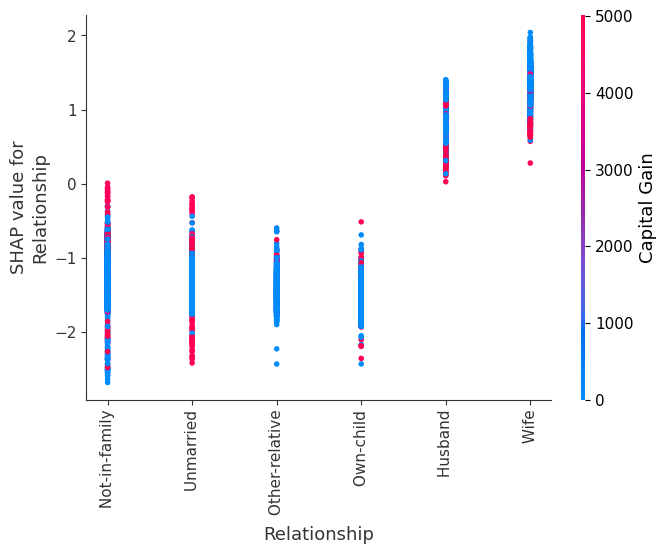

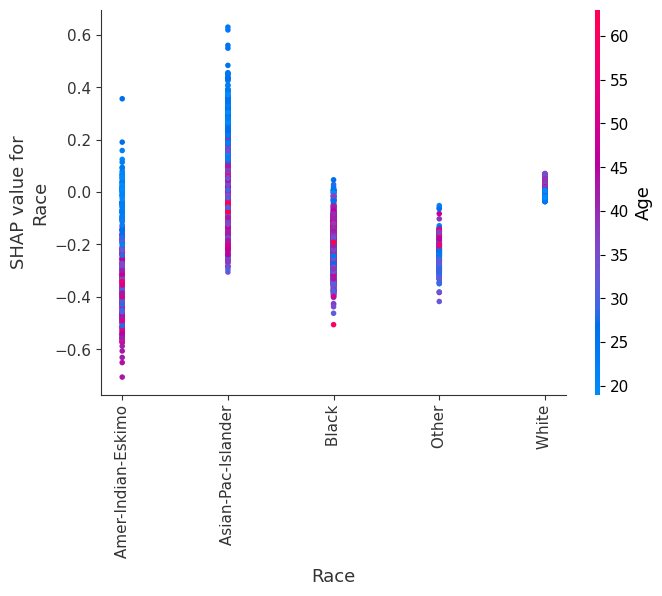

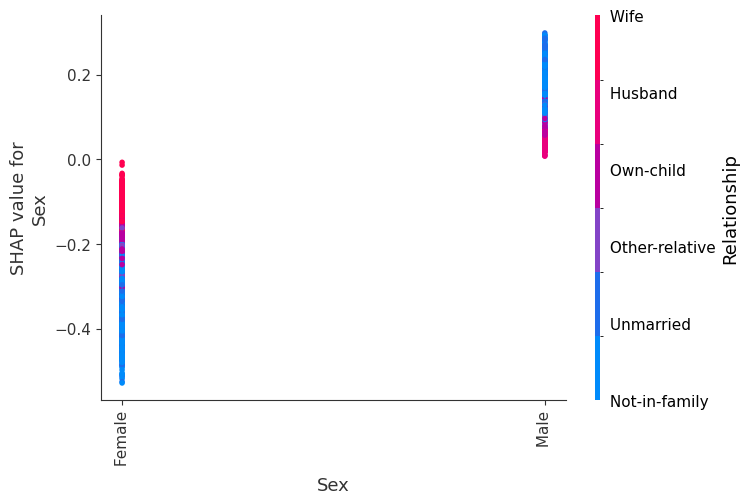

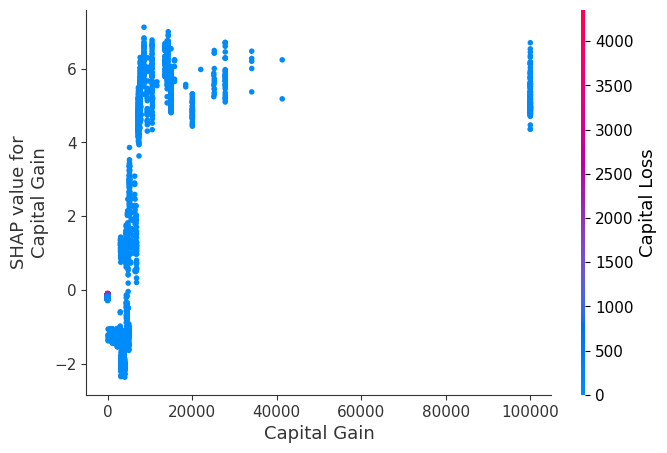

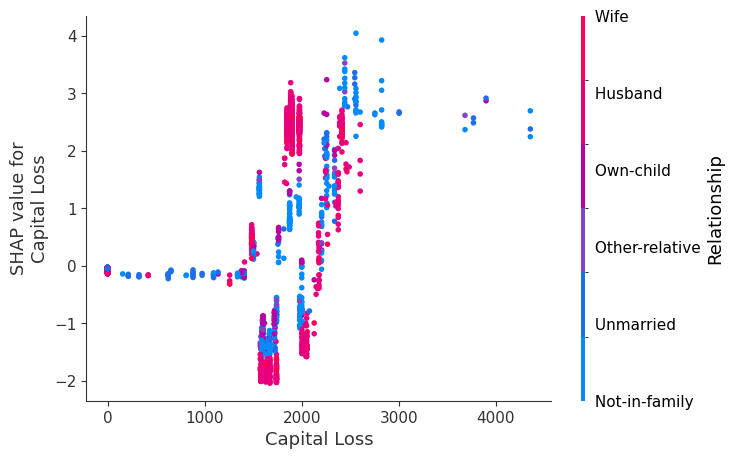

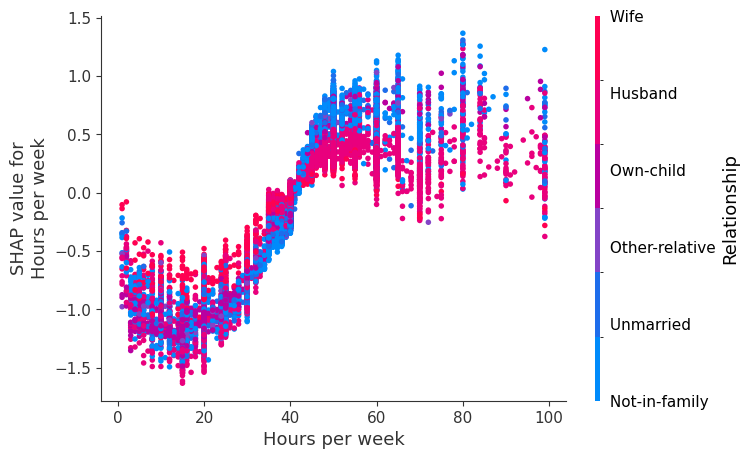

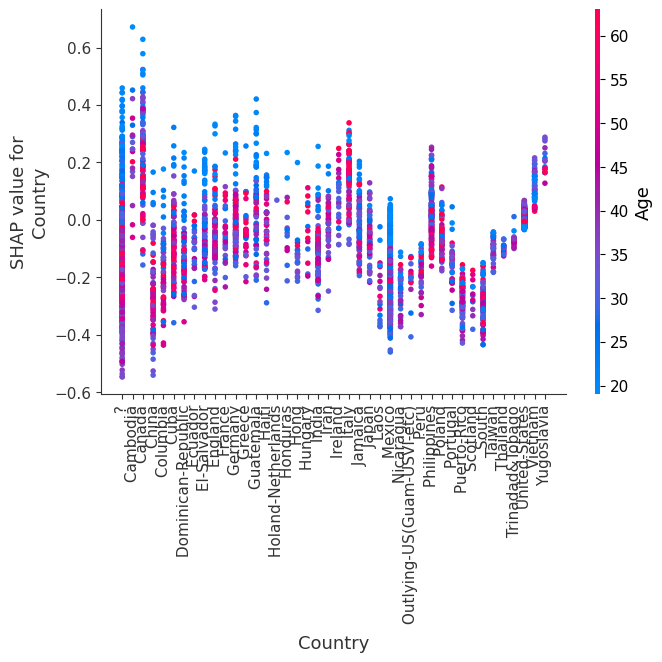

In [18]:
for name in X_train.columns:
    shap.dependence_plot(name, shap_values, X, display_features=X_display)

SHAP beeswarm plot, which is one of the most useful plots for getting a global overview of a machine-learning model.

It answers two questions at the same time:

Which features are most important overall?
For each feature, do its values push predictions higher or lower?

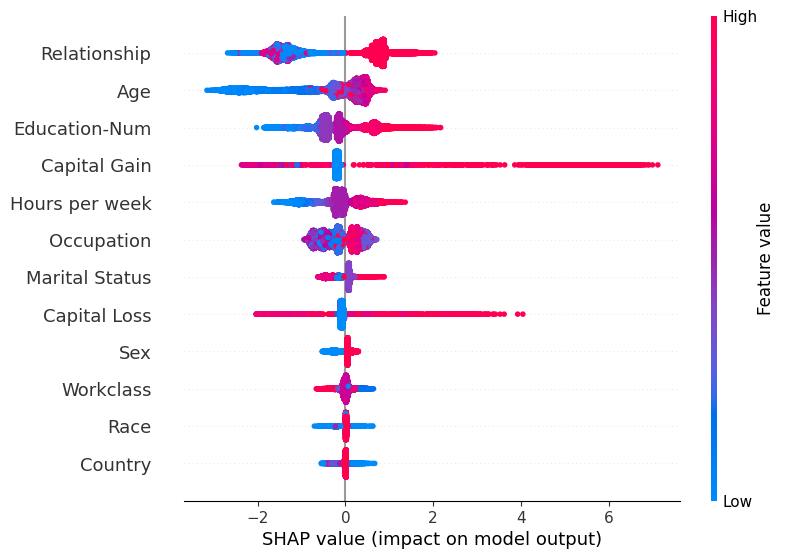

In [19]:
shap_exp = explainer(X)

shap.plots.beeswarm(
    shap_exp,
    max_display=15
)

A SHAP waterfall plot explains why the model made a particular prediction for one observation.

The easiest way to understand it is:

Start with the base value → add/subtract each feature's SHAP contribution → arrive at the final prediction \(f(x)\).

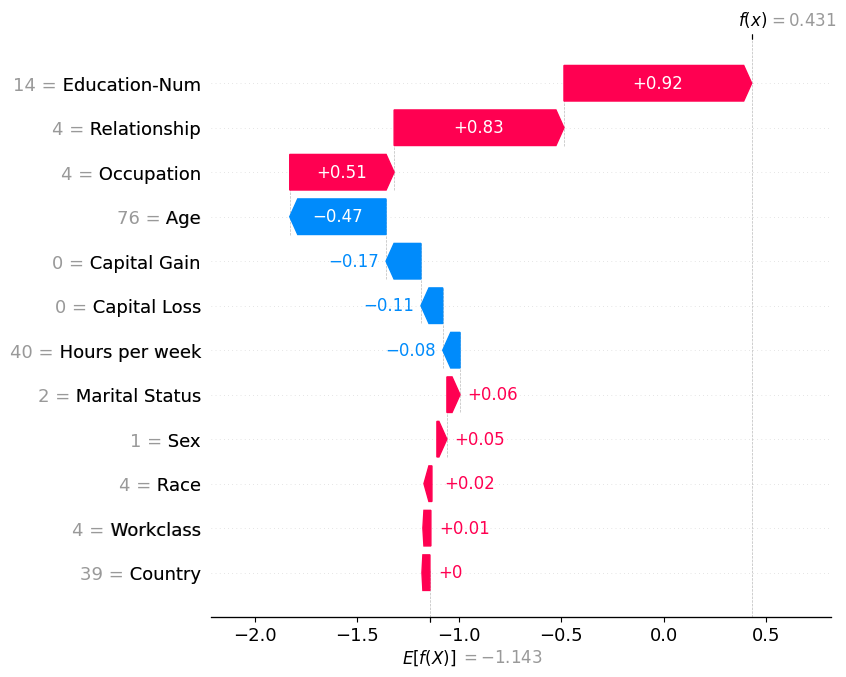

In [20]:
# 4. Waterfall plot
shap.plots.waterfall(shap_exp[100], max_display=15)

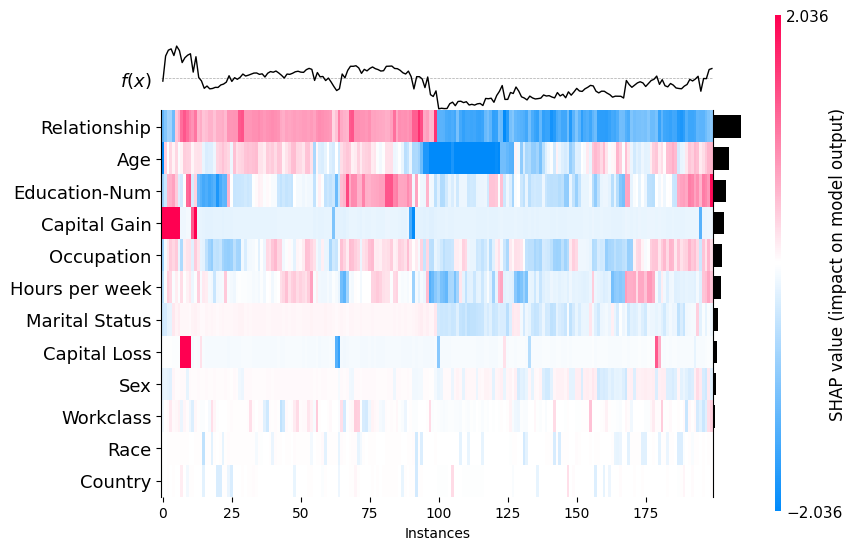

<Axes: xlabel='Instances'>

In [21]:
# 3. Heatmap
shap.plots.heatmap(shap_exp[:200], max_display=15)

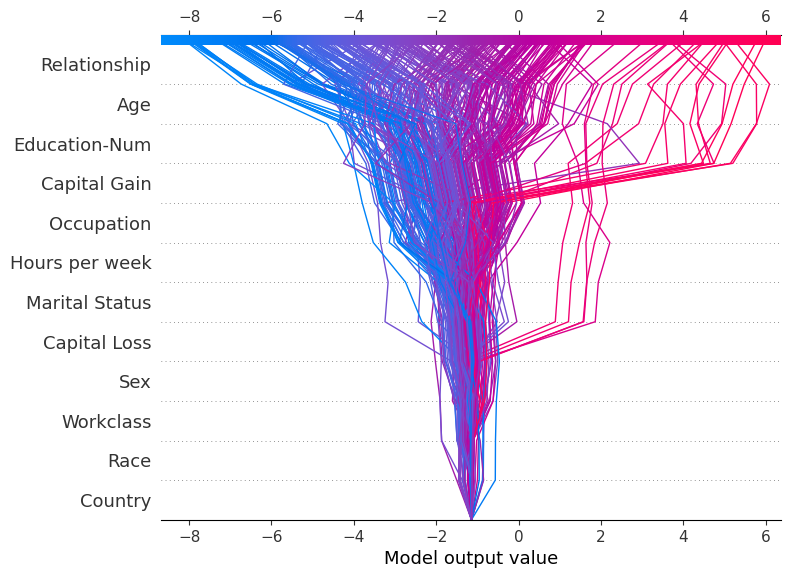

In [22]:
import shap
import matplotlib.pyplot as plt

# Create a smaller sample for a clear plot
X_sample = X.iloc[:300]
shap_sample = shap_values[:300]

shap.decision_plot(
    explainer.expected_value,
    shap_sample,
    X_sample
)



# Explainable AI Using SHAP

### Dataset

Use the **Breast Cancer Wisconsin Diagnostic Dataset** available through `scikit-learn` to build a machine learning model for classifying breast tumours as **malignant or benign** based on their measured characteristics.

### Objective

In this experiment, apply **SHAP (SHapley Additive exPlanations)** as an Explainable AI (XAI) technique to understand how individual features contribute to the predictions made by the trained machine learning model.

The following SHAP visualizations should be used:

* **SHAP Bar Plot** – to identify the globally most important features.
* **SHAP Summary/Beeswarm Plot** – to understand the direction, magnitude, and distribution of feature effects.
* **SHAP Waterfall Plot** – to explain the contribution of features for an individual prediction.
* **SHAP Dependence Plot** – to understand how a feature affects model predictions across different feature values.
* **SHAP Force Plot** – to visualize how features push an individual prediction toward malignant or benign.

### Task 1: Load and Prepare the Dataset

* Load the Breast Cancer Wisconsin Diagnostic dataset using `sklearn.datasets`.
* Display the first few records.
* Check the dataset dimensions, data types, and missing values.
* Display the feature names.
* Display the target classes.
* Display descriptive statistics of the input features.
* Separate the input features (`X`) and target variable (`y`).
* Split the data into training and testing sets.

**Comment:**

Explain the structure of the dataset, the target variable, and the purpose of separating the data into training and testing sets.

---

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load dataset
data = load_breast_cancer()

# Create DataFrame
X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Dataset loaded successfully.")
print("Dataset shape:", X.shape)

print("\nFirst five records:")
display(X.head())

print("\nData types:")
print(X.dtypes)

print("\nMissing values:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())

print("\nFeature names:")
for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

print("\nTarget classes:")
print(data.target_names)

print("\nTarget distribution:")
print(y.value_counts())

print("\nDescriptive statistics:")
display(X.describe())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Dataset loaded successfully.
Dataset shape: (569, 30)

First five records:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst s

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Training set shape: (426, 30)
Testing set shape: (143, 30)


### Task 2: Train a Machine Learning Model

* Select an appropriate machine learning algorithm for classifying breast tumours.
* Train the model using the training dataset.
* Generate predictions for the test dataset.
* Generate prediction probabilities.
* Evaluate the model using suitable performance metrics.
* Report the model performance on the test dataset.

Use a classification model such as **Random Forest Classifier**.

**Comment:**

Explain why the selected machine learning algorithm is appropriate for this dataset and discuss the obtained model performance.

---

In [5]:
# Create Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=400,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [6]:
# Generate predictions
y_pred = model.predict(X_test)

# Generate prediction probabilities
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [7]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nRandom Forest Performance")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)


Random Forest Performance
-------------------------
Accuracy : 0.9580
ROC-AUC  : 0.9941

Classification Report:
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



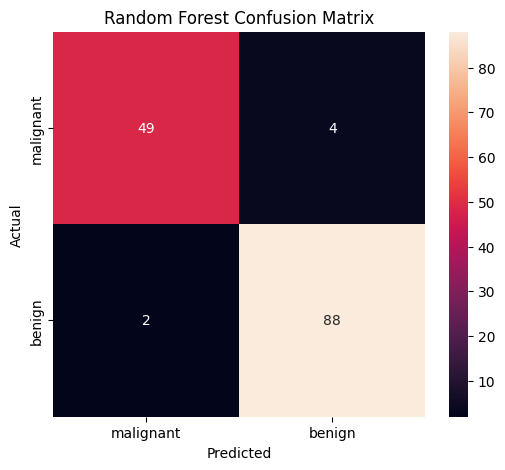

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

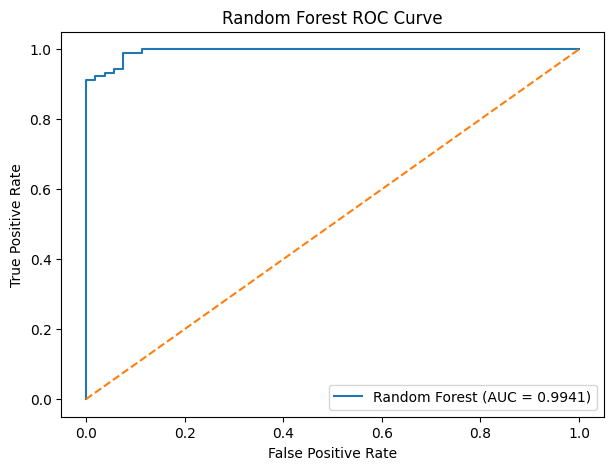

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

### Task 3: Create a SHAP Explainer

* Import the SHAP library.
* Create an appropriate SHAP explainer for the trained machine learning model.
* Calculate the SHAP values for the test dataset.
* Examine the shape of the generated SHAP values.

**Comment:**

Explain:

1. What SHAP stands for.
2. What a SHAP value represents.
3. What a positive SHAP value indicates.
4. What a negative SHAP value indicates.
5. What a SHAP value close to zero means.
6. Why SHAP can be used to explain machine learning predictions.

---

In [10]:
import shap
import numpy as np

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")

print("Type of SHAP values:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP arrays:", len(shap_values))
    for i, values in enumerate(shap_values):
        print(f"Class {i} SHAP shape:", values.shape)
else:
    print("SHAP values shape:", shap_values.shape)

print("Expected value:", explainer.expected_value)

SHAP values calculated successfully.
Type of SHAP values: <class 'numpy.ndarray'>
SHAP values shape: (143, 30, 2)
Expected value: [0.37386737 0.62613263]


### Task 4: SHAP Feature Importance – Bar Plot

Generate a **SHAP bar plot** showing the global importance of the input features.

* Calculate the mean absolute SHAP value for each feature.
* Rank the features according to their SHAP importance.
* Display the most important features using a bar chart.

**Comment:**

Identify the **top five most important features** and explain how the SHAP bar plot helps in understanding the **global behaviour** of the trained model.

---


In [11]:
# Prepare SHAP values for the positive/benign class
if isinstance(shap_values, list):
    shap_for_class = shap_values[1]
else:
    if len(shap_values.shape) == 3:
        shap_for_class = shap_values[:, :, 1]
    else:
        shap_for_class = shap_values

# Mean absolute SHAP value
mean_abs_shap = np.abs(shap_for_class).mean(axis=0)

# Create feature importance table
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Absolute SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

print("SHAP Feature Importance:")
display(shap_importance)

print("\nTop 5 most important features:")
display(shap_importance.head(5))

SHAP Feature Importance:


,Feature,Mean Absolute SHAP
23,worst area,0.071351
22,worst perimeter,0.064996
27,worst concave points,0.054466
7,mean concave points,0.044896
20,worst radius,0.042307
6,mean concavity,0.024053
0,mean radius,0.022886
2,mean perimeter,0.022690
3,mean area,0.020591
13,area error,0.019652



Top 5 most important features:


,Feature,Mean Absolute SHAP
23,worst area,0.071351
22,worst perimeter,0.064996
27,worst concave points,0.054466
7,mean concave points,0.044896
20,worst radius,0.042307


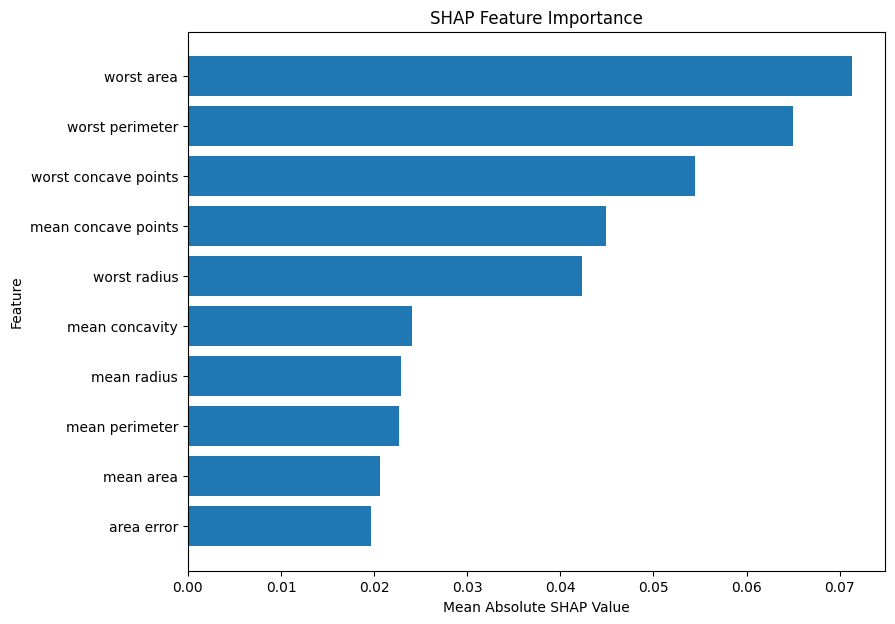

In [12]:
plt.figure(figsize=(9, 7))

top_features = shap_importance.head(10)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Mean Absolute SHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance")
plt.show()

### Task 5: SHAP Summary / Beeswarm Plot

Generate a **SHAP summary (beeswarm) plot** for the input features.

Use the plot to investigate:

* Feature importance
* SHAP value magnitude
* Positive and negative feature effects
* High and low feature values
* Distribution of SHAP values

**Comment:**

For the three most important features, explain:

1. How high feature values affect the prediction.
2. How low feature values affect the prediction.
3. Whether the feature generally pushes the prediction toward malignant or benign.
4. Whether the relationship appears linear or nonlinear.

---

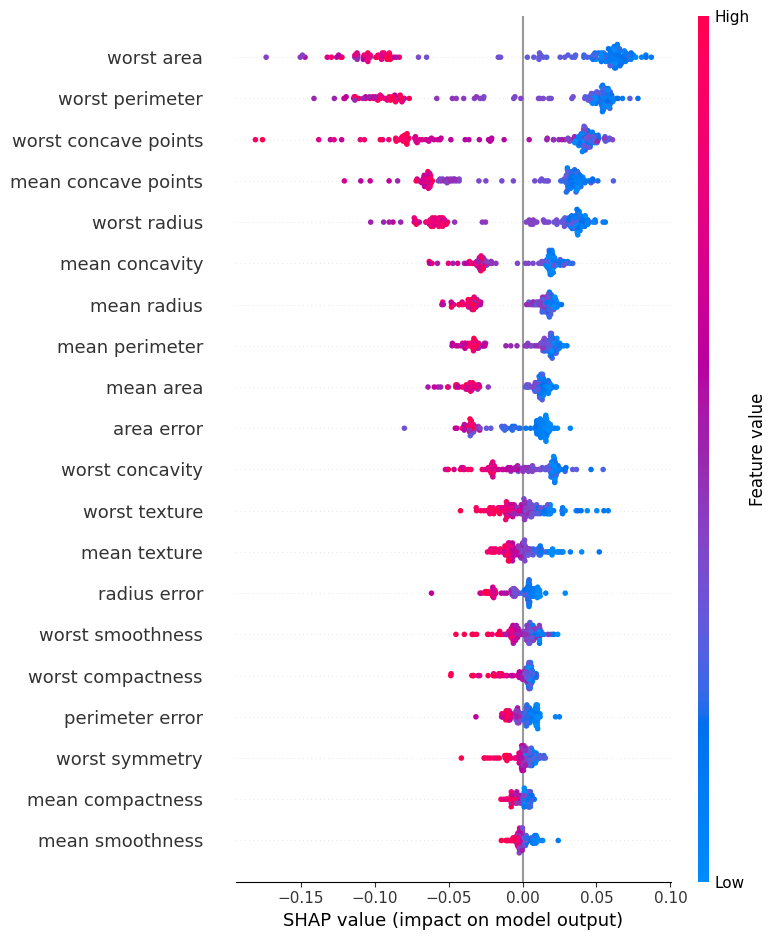

In [13]:
shap.summary_plot(
    shap_for_class,
    X_test,
    feature_names=X_test.columns,
    show=True
)

### Task 6: SHAP Waterfall Plot

Select at least **one individual tumour sample** from the test dataset.

Generate a **SHAP waterfall plot** to explain its prediction.

Display:

* The base/expected value.
* Individual feature contributions.
* Features that push the prediction toward malignant.
* Features that push the prediction toward benign.
* The final model prediction.

**Comment:**

Explain how each important feature contributes to the prediction of the selected tumour sample.

---

In [14]:
# ============================================================
# TASK 6: SHAP WATERFALL PLOT
# ============================================================

# Select one individual test sample
sample_index = 0

X_sample = X_test.iloc[[sample_index]]
y_actual = y_test.iloc[sample_index]
y_prediction = y_pred[sample_index]
prediction_probability = y_prob[sample_index]

print("Selected Test Sample")
print("--------------------")
print("Test sample index:", sample_index)
print("Actual class:", data.target_names[y_actual])
print("Predicted class:", data.target_names[y_prediction])

print("\nPrediction probabilities:")
print("Malignant:", model.predict_proba(X_sample)[0][0])
print("Benign   :", model.predict_proba(X_sample)[0][1])

# Calculate SHAP explanation for this sample
sample_explanation = explainer(X_sample)

print("\nSHAP explanation created successfully.")
print("Explanation shape:", sample_explanation.values.shape)

Selected Test Sample
--------------------
Test sample index: 0
Actual class: benign
Predicted class: benign

Prediction probabilities:
Malignant: 0.0125
Benign   : 0.9875

SHAP explanation created successfully.
Explanation shape: (1, 30, 2)


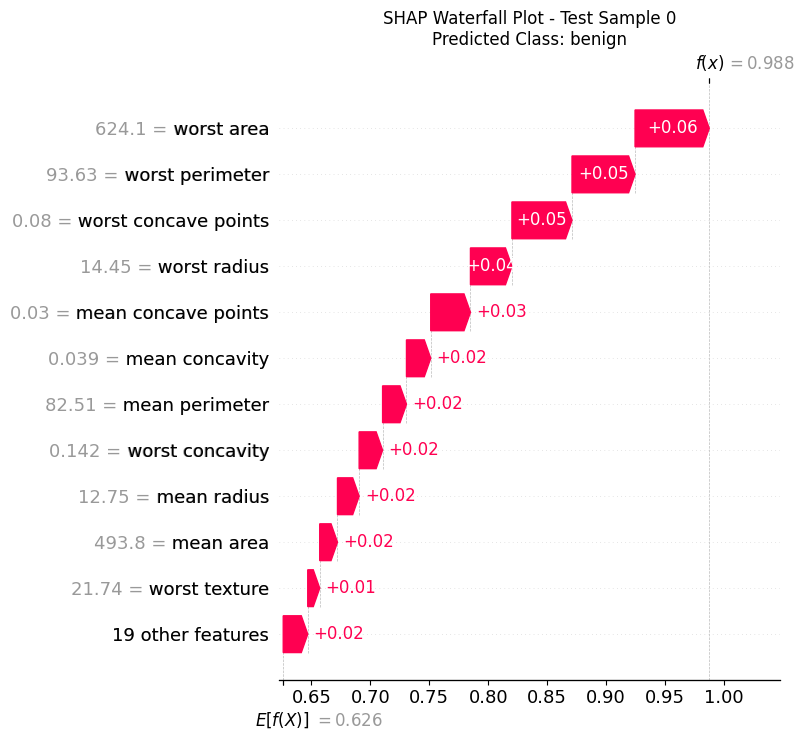

In [15]:
# Determine the predicted class
predicted_class = int(y_prediction)

# Extract SHAP values for the predicted class
if len(sample_explanation.values.shape) == 3:
    sample_values = sample_explanation.values[0, :, predicted_class]
    sample_base_value = sample_explanation.base_values[0, predicted_class]
else:
    sample_values = sample_explanation.values[0]

    if np.ndim(sample_explanation.base_values) > 0:
        sample_base_value = sample_explanation.base_values[0]
    else:
        sample_base_value = sample_explanation.base_values

# Create a single-sample SHAP Explanation
waterfall_explanation = shap.Explanation(
    values=sample_values,
    base_values=sample_base_value,
    data=X_sample.iloc[0].values,
    feature_names=X_test.columns.tolist()
)

# Generate waterfall plot
plt.figure(figsize=(10, 7))

shap.plots.waterfall(
    waterfall_explanation,
    max_display=12,
    show=False
)

plt.title(
    f"SHAP Waterfall Plot - Test Sample {sample_index}\n"
    f"Predicted Class: {data.target_names[y_prediction]}"
)

plt.tight_layout()
plt.show()

### Task 7: SHAP Force Plot

Generate a **SHAP force plot** for the same individual sample used in Task 6.

**Comment:**

Explain:

1. Which features push the prediction toward malignant?
2. Which features push the prediction toward benign?
3. Which feature has the largest contribution?
4. How does the force plot represent the movement from the base value to the final prediction?

Compare the force plot with the waterfall plot.

---

SHAP Force Plot
----------------
Using the same test sample as Task 6.
Test sample index: 0
Actual class: benign
Predicted class: benign


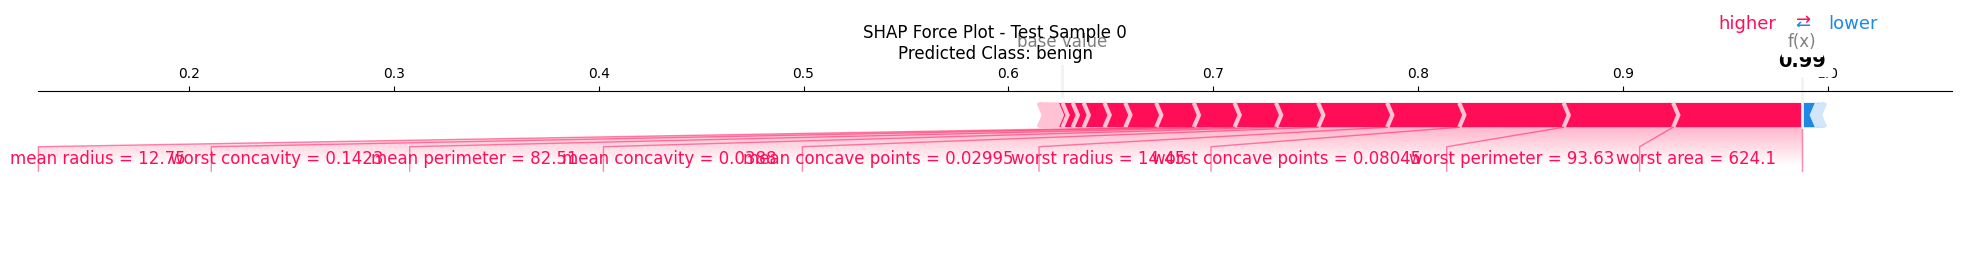

In [16]:
# ============================================================
# TASK 7: SHAP FORCE PLOT
# ============================================================

print("SHAP Force Plot")
print("----------------")
print("Using the same test sample as Task 6.")
print("Test sample index:", sample_index)
print("Actual class:", data.target_names[y_actual])
print("Predicted class:", data.target_names[y_prediction])

# Generate force plot
force_plot = shap.force_plot(
    sample_base_value,
    sample_values,
    X_sample.iloc[0],
    feature_names=X_test.columns.tolist(),
    matplotlib=True,
    show=False
)

plt.title(
    f"SHAP Force Plot - Test Sample {sample_index}\n"
    f"Predicted Class: {data.target_names[y_prediction]}"
)

plt.tight_layout()
plt.show()

### Task 8: SHAP Dependence Plot

Generate SHAP dependence plots for three important features identified from the SHAP analysis.

For example:

* `mean radius`
* `mean perimeter`
* `mean concavity`

**Comment:**

For each feature, explain:

1. How the feature value affects the SHAP value.
2. Whether increasing the feature increases or decreases the prediction.
3. Whether the relationship is linear or nonlinear.
4. Whether the effect changes at different feature values.
5. Whether any possible feature interaction can be observed.

---

In [17]:
# ============================================================
# TASK 8: SHAP DEPENDENCE PLOTS
# ============================================================

# Calculate mean absolute SHAP importance
mean_abs_shap = np.abs(shap_for_class).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Absolute SHAP": mean_abs_shap
}).sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

# Select top 3 important features
top_3_features = shap_importance.head(3)["Feature"].tolist()

print("Top 3 features selected for dependence analysis:")

for i, feature in enumerate(top_3_features, start=1):
    print(f"{i}. {feature}")

Top 3 features selected for dependence analysis:
1. worst area
2. worst perimeter
3. worst concave points


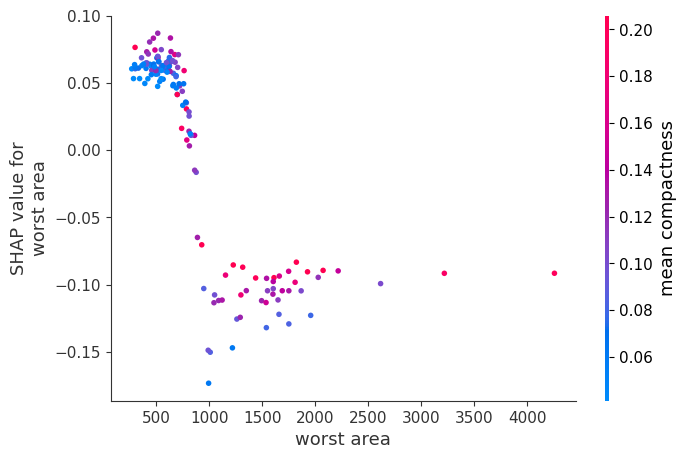

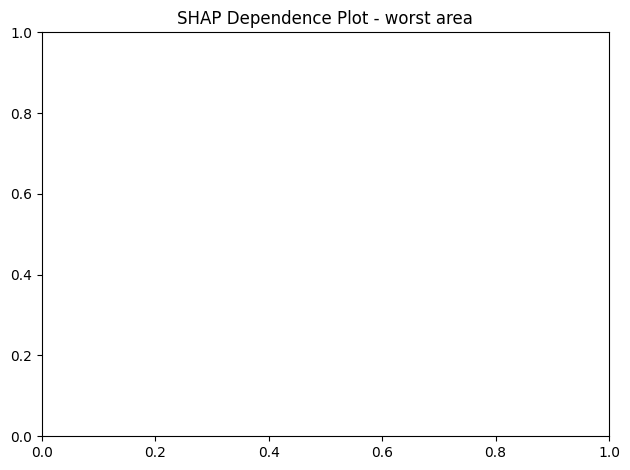

In [18]:
# Dependence Plot 1

shap.dependence_plot(
    top_3_features[0],
    shap_for_class,
    X_test,
    interaction_index="auto"
)

plt.title(f"SHAP Dependence Plot - {top_3_features[0]}")
plt.tight_layout()
plt.show()

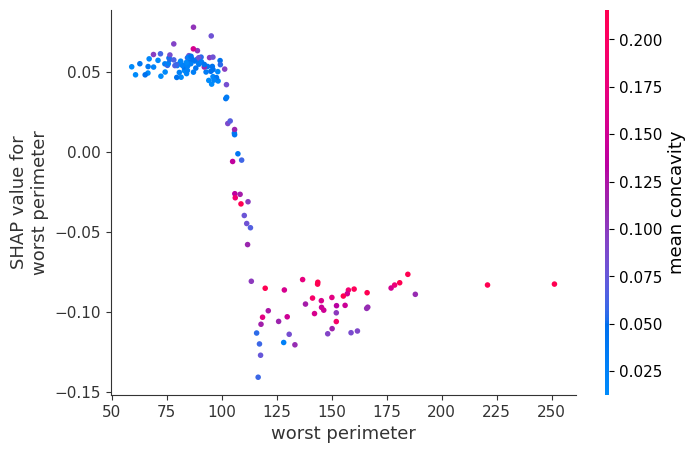

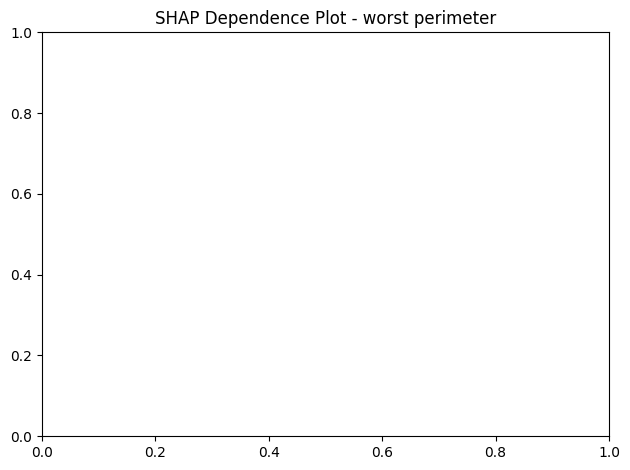

In [19]:
# Dependence Plot 2

shap.dependence_plot(
    top_3_features[1],
    shap_for_class,
    X_test,
    interaction_index="auto"
)

plt.title(f"SHAP Dependence Plot - {top_3_features[1]}")
plt.tight_layout()
plt.show()

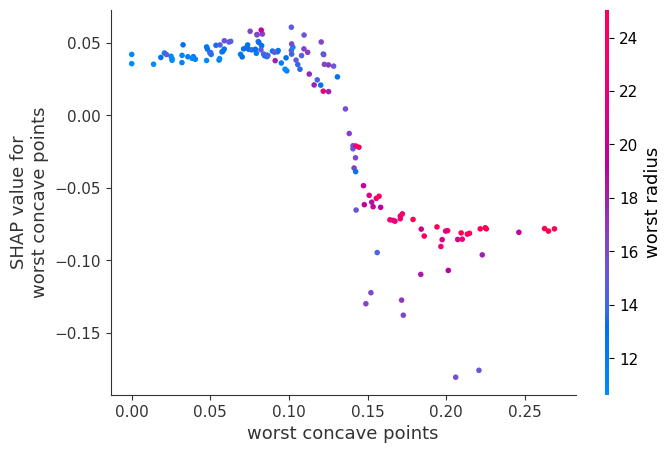

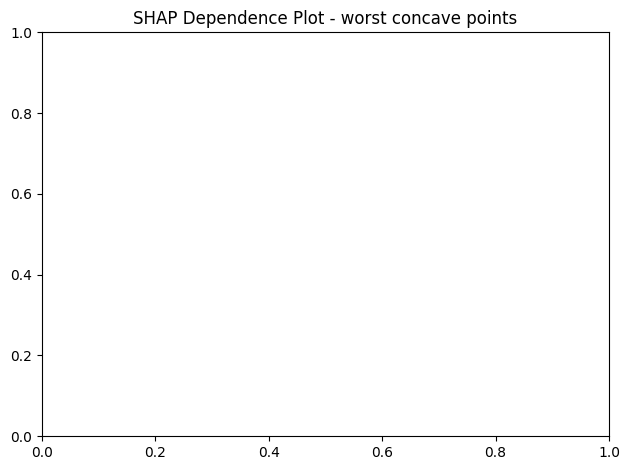

In [20]:
# Dependence Plot 3

shap.dependence_plot(
    top_3_features[2],
    shap_for_class,
    X_test,
    interaction_index="auto"
)

plt.title(f"SHAP Dependence Plot - {top_3_features[2]}")
plt.tight_layout()
plt.show()

### Task 9: Compare SHAP Explanations for Different Samples

Select at least **three different tumour samples** from the test dataset.

Generate SHAP explanations for each sample.

Compare their predictions and feature contributions.

**Comment:**

Explain:

1. Why can the same feature have different SHAP values for different samples?
2. Which features are consistently important?
3. Which features show different effects across samples?
4. How does this demonstrate the difference between **global and local explanations**?

---

In [21]:
# ============================================================
# TASK 9: COMPARE SHAP EXPLANATIONS FOR 3 SAMPLES
# ============================================================

# Select three different test samples
sample_indices = [0, 1, 2]

comparison_data = []

for idx in sample_indices:
    actual = int(y_test.iloc[idx])
    predicted = int(y_pred[idx])
    probability = model.predict_proba(X_test.iloc[[idx]])[0][predicted]

    comparison_data.append({
        "Sample": idx,
        "Actual Class": data.target_names[actual],
        "Predicted Class": data.target_names[predicted],
        "Prediction Probability": probability
    })

sample_comparison = pd.DataFrame(comparison_data)

display(sample_comparison)

,Sample,Actual Class,Predicted Class,Prediction Probability
0,0,benign,benign,0.9875
1,1,malignant,malignant,1.0000
2,2,benign,benign,0.6600


Sample 0 | Actual: benign | Predicted: benign


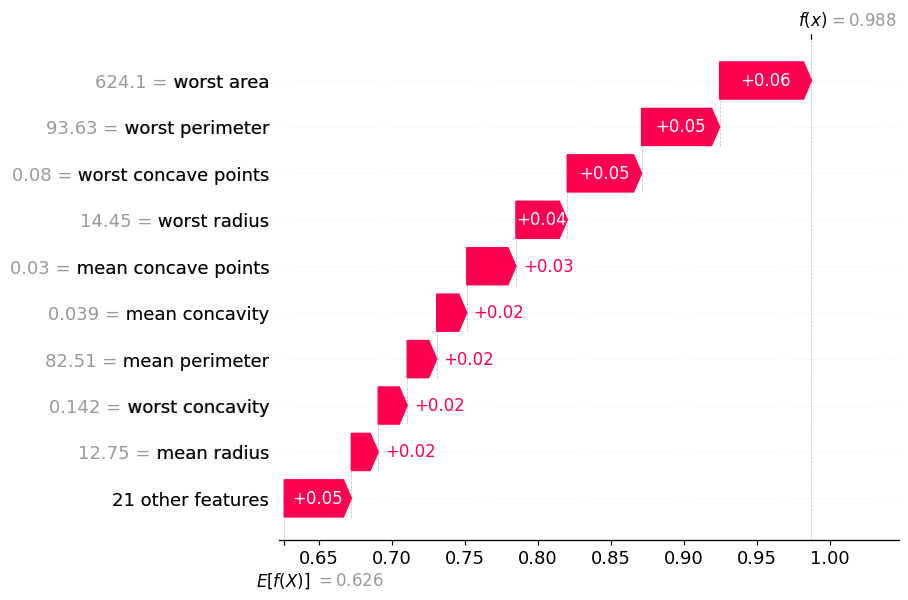

Sample 1 | Actual: malignant | Predicted: malignant


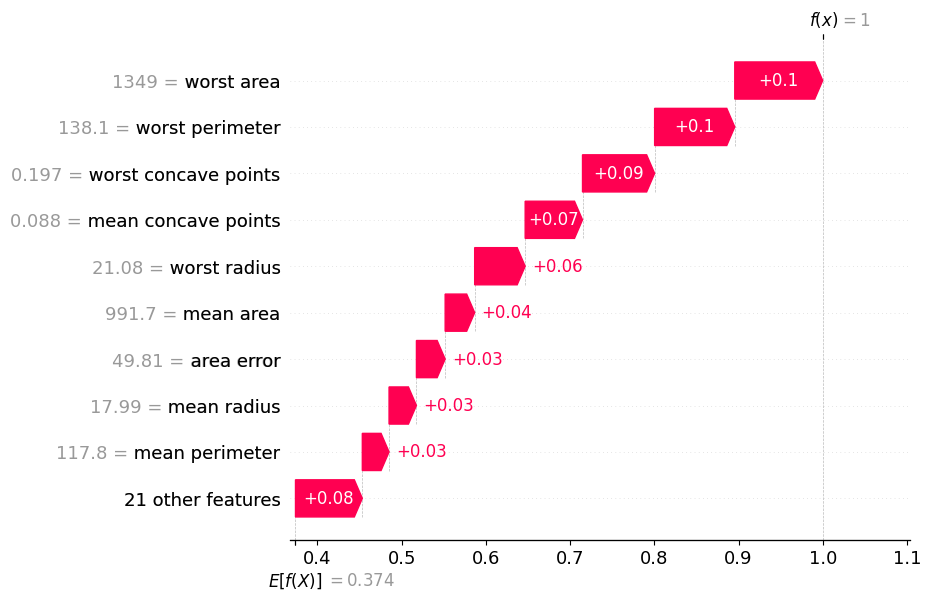

Sample 2 | Actual: benign | Predicted: benign


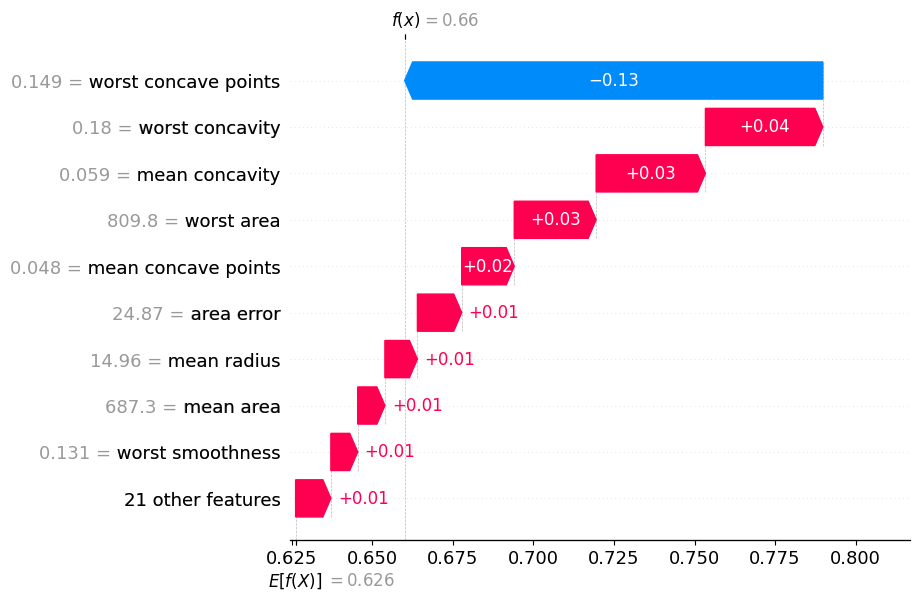

In [22]:
# Generate SHAP waterfall explanations for the three samples

for idx in sample_indices:

    sample_exp = explainer(X_test.iloc[[idx]])

    # Handle different SHAP output formats
    if len(sample_exp.values.shape) == 3:
        predicted_class = int(y_pred[idx])

        values = sample_exp.values[0, :, predicted_class]
        base_value = sample_exp.base_values[0, predicted_class]
    else:
        values = sample_exp.values[0]
        base_value = sample_exp.base_values[0]

    explanation = shap.Explanation(
        values=values,
        base_values=base_value,
        data=X_test.iloc[idx].values,
        feature_names=X_test.columns.tolist()
    )

    print(
        f"Sample {idx} | "
        f"Actual: {data.target_names[y_test.iloc[idx]]} | "
        f"Predicted: {data.target_names[y_pred[idx]]}"
    )

    shap.plots.waterfall(
        explanation,
        max_display=10
    )

    plt.show()



### Task 10: Compare SHAP with Model Feature Importance

Calculate the built-in feature importance of the Random Forest model.

Compare it with the SHAP feature importance obtained in Task 4.

**Comment:**

Discuss:

1. Are the top-ranked features the same?
2. If there are differences, why might they occur?
3. What additional information does SHAP provide?
4. Why is feature importance alone insufficient for understanding individual predictions?

---

In [23]:
# ============================================================
# TASK 10: SHAP VS RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Random Forest built-in feature importance
rf_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Random Forest Importance": model.feature_importances_
})

# SHAP importance
shap_compare = shap_importance.copy()

# Merge both rankings
comparison = pd.merge(
    shap_compare,
    rf_importance,
    on="Feature"
)

# Add rankings
comparison["SHAP Rank"] = (
    comparison["Mean Absolute SHAP"]
    .rank(ascending=False, method="min")
    .astype(int)
)

comparison["RF Rank"] = (
    comparison["Random Forest Importance"]
    .rank(ascending=False, method="min")
    .astype(int)
)

comparison = comparison.sort_values("SHAP Rank")

display(comparison)

,Feature,Mean Absolute SHAP,Random Forest Importance,SHAP Rank,RF Rank
0,worst area,0.071351,0.141782,1,1
1,worst perimeter,0.064996,0.134490,2,2
2,worst concave points,0.054466,0.116966,3,3
3,mean concave points,0.044896,0.094091,4,4
4,worst radius,0.042307,0.076999,5,5
5,mean concavity,0.024053,0.048372,6,8
6,mean radius,0.022886,0.057158,7,6
7,mean perimeter,0.022690,0.055324,8,7
8,mean area,0.020591,0.040569,9,9
9,area error,0.019652,0.034246,10,10


In [24]:
# Display top 10 features according to both methods

print("Top 10 Features According to SHAP:")
display(
    comparison
    .sort_values("SHAP Rank")
    .head(10)
)

print("\nTop 10 Features According to Random Forest:")
display(
    comparison
    .sort_values("RF Rank")
    .head(10)
)

Top 10 Features According to SHAP:


,Feature,Mean Absolute SHAP,Random Forest Importance,SHAP Rank,RF Rank
0,worst area,0.071351,0.141782,1,1
1,worst perimeter,0.064996,0.134490,2,2
2,worst concave points,0.054466,0.116966,3,3
3,mean concave points,0.044896,0.094091,4,4
4,worst radius,0.042307,0.076999,5,5
5,mean concavity,0.024053,0.048372,6,8
6,mean radius,0.022886,0.057158,7,6
7,mean perimeter,0.022690,0.055324,8,7
8,mean area,0.020591,0.040569,9,9
9,area error,0.019652,0.034246,10,10



Top 10 Features According to Random Forest:


,Feature,Mean Absolute SHAP,Random Forest Importance,SHAP Rank,RF Rank
0,worst area,0.071351,0.141782,1,1
1,worst perimeter,0.064996,0.134490,2,2
2,worst concave points,0.054466,0.116966,3,3
3,mean concave points,0.044896,0.094091,4,4
4,worst radius,0.042307,0.076999,5,5
6,mean radius,0.022886,0.057158,7,6
7,mean perimeter,0.022690,0.055324,8,7
5,mean concavity,0.024053,0.048372,6,8
8,mean area,0.020591,0.040569,9,9
9,area error,0.019652,0.034246,10,10


### Task 11: Compare Different SHAP Plots

Compare the following SHAP visualizations:

| SHAP Plot | Main Purpose |
|---|---|
| SHAP Bar Plot | Global feature importance |
| SHAP Beeswarm Plot | Feature importance and direction of effects |
| SHAP Waterfall Plot | Explanation of one individual prediction |
| SHAP Force Plot | Individual feature contributions |
| SHAP Dependence Plot | Relationship between feature values and SHAP values |

**Comment:**

Explain why different SHAP plots are required to obtain a complete understanding of the machine learning model.

---

Comment: The SHAP visualizations provide complementary information about the trained Random Forest model. The SHAP Bar Plot provides a global ranking of feature importance based on mean absolute SHAP values. The Beeswarm Plot provides both feature importance and the direction and distribution of feature effects. The Waterfall Plot explains how individual features contribute to one particular prediction. The Force Plot presents the same local contributions in a visual force-based representation. The Dependence Plot shows how the value of a feature is related to its SHAP contribution and can also reveal nonlinear relationships and possible feature interactions. Therefore, using multiple SHAP plots provides a more complete understanding than relying on a single visualization.

### Task 12: Global vs Local Explainability

Using the SHAP plots generated in the previous tasks, explain the difference between:

**Global Explanation**

> How does the model generally classify breast tumour samples?

**Local Explanation**

> Why did the model classify this particular tumour sample as malignant or benign?

**Comment:**

Use examples from the SHAP bar/beeswarm plots and waterfall/force plots to support your explanation.

---

Global Explanation: SHAP Bar and Beeswarm plots describe the general behaviour of the Random Forest model across the test dataset. They identify the features that have the greatest overall influence on tumour classification and show whether high or low feature values tend to push predictions toward malignant or benign.

Local Explanation: SHAP Waterfall and Force plots explain the prediction of an individual tumour sample. They show how the individual feature values move the model output away from the base value toward the final prediction.

Comment: Global explanations are useful for understanding the overall decision behaviour of the model, whereas local explanations are useful for understanding why a particular tumour was classified as malignant or benign. Both perspectives are necessary because an important feature globally may have a different contribution for an individual sample.

### Task 13: Analyse Feature Interactions

Use SHAP dependence analysis to investigate whether two important features interact with each other.

**Comment:**

Discuss:

1. Which two features appear to interact?
2. How does one feature influence the effect of another feature?
3. Why are feature interactions important for understanding model behaviour?
4. Can the effect of a feature change depending on the value of another feature?

---


In [25]:
# ============================================================
# TASK 13: FEATURE INTERACTION ANALYSIS
# ============================================================

top_feature_1 = top_3_features[0]
top_feature_2 = top_3_features[1]

print("Feature 1:", top_feature_1)
print("Feature 2:", top_feature_2)

Feature 1: worst area
Feature 2: worst perimeter


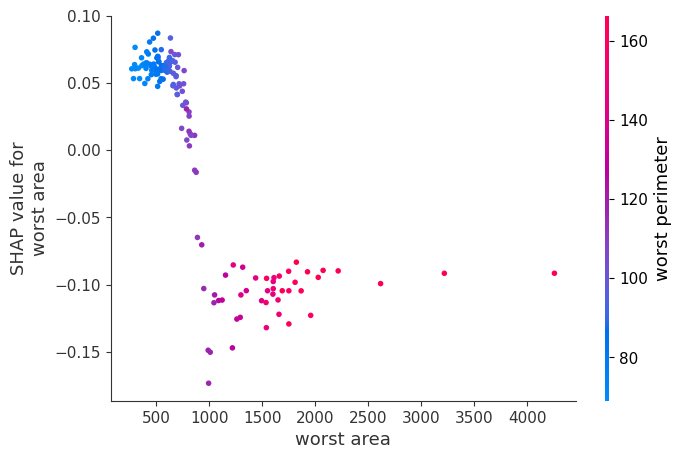

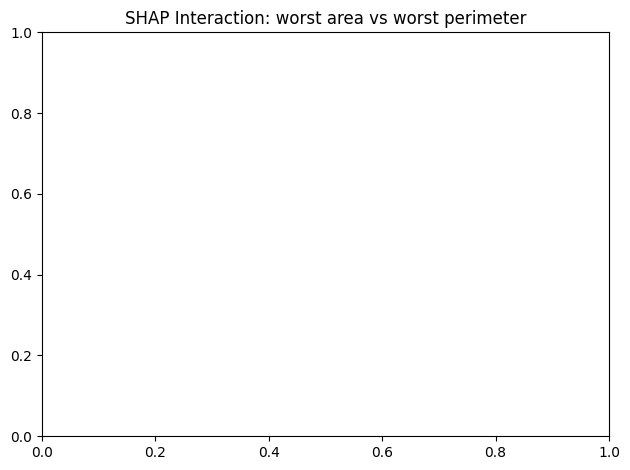

In [26]:
# Dependence plot showing possible interaction
# between the two most important SHAP features

shap.dependence_plot(
    top_feature_1,
    shap_for_class,
    X_test,
    interaction_index=top_feature_2
)

plt.title(
    f"SHAP Interaction: {top_feature_1} vs {top_feature_2}"
)

plt.tight_layout()
plt.show()

### Task 14: SHAP-Based Model Analysis

Based on all the SHAP visualizations, identify:

* The five most important features.
* The feature that has the strongest positive contribution toward the predicted class.
* The feature that has the strongest negative contribution.
* Features with nonlinear effects.
* Features that show possible interactions.
* Features that consistently influence individual predictions.

**Comment:**

Explain how the SHAP analysis provides a deeper understanding of the model than simply looking at classification accuracy.

---

In [27]:
# ============================================================
# TASK 14: SHAP-BASED MODEL ANALYSIS
# ============================================================

# Top 5 features
top_5 = shap_importance.head(5)

print("Five Most Important Features:")
display(top_5)

Five Most Important Features:


,Feature,Mean Absolute SHAP
23,worst area,0.071351
22,worst perimeter,0.064996
27,worst concave points,0.054466
7,mean concave points,0.044896
20,worst radius,0.042307


In [28]:
# Strongest positive and negative SHAP contributions

max_position = np.unravel_index(
    np.argmax(shap_for_class),
    shap_for_class.shape
)

min_position = np.unravel_index(
    np.argmin(shap_for_class),
    shap_for_class.shape
)

max_sample = max_position[0]
max_feature_index = max_position[1]

min_sample = min_position[0]
min_feature_index = min_position[1]

print("Strongest positive SHAP contribution")
print("-------------------------------------")
print("Sample:", max_sample)
print("Feature:", X_test.columns[max_feature_index])
print("SHAP value:", shap_for_class[max_sample, max_feature_index])

print("\nStrongest negative SHAP contribution")
print("-------------------------------------")
print("Sample:", min_sample)
print("Feature:", X_test.columns[min_feature_index])
print("SHAP value:", shap_for_class[min_sample, min_feature_index])

Strongest positive SHAP contribution
-------------------------------------
Sample: 62
Feature: worst area
SHAP value: 0.08707034537358081

Strongest negative SHAP contribution
-------------------------------------
Sample: 6
Feature: worst concave points
SHAP value: -0.18052088004514827


In [29]:
# Features showing the largest variation in SHAP values

shap_variation = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Std": np.std(shap_for_class, axis=0),
    "Mean Absolute SHAP": np.mean(
        np.abs(shap_for_class),
        axis=0
    )
})

shap_variation = shap_variation.sort_values(
    "SHAP Std",
    ascending=False
)

print("Features with greatest SHAP variation:")
display(shap_variation.head(10))

Features with greatest SHAP variation:


,Feature,SHAP Std,Mean Absolute SHAP
23,worst area,0.077660,0.071351
22,worst perimeter,0.070314,0.064996
27,worst concave points,0.060982,0.054466
7,mean concave points,0.048360,0.044896
20,worst radius,0.046051,0.042307
6,mean concavity,0.025871,0.024053
0,mean radius,0.025348,0.022886
2,mean perimeter,0.024553,0.022690
3,mean area,0.024196,0.020591
13,area error,0.022702,0.019652


### Task 15: Explain a Misclassified Sample

Identify at least **one incorrectly classified sample** from the test dataset.

Generate a SHAP waterfall plot for the misclassified sample.

**Comment:**

Explain:

1. What was the actual class?
2. What class did the model predict?
3. Which features contributed most strongly to the incorrect prediction?
4. Were there features pushing the prediction toward the correct class?
5. What does the SHAP explanation reveal about the model's error?

---

In [30]:
# ============================================================
# TASK 15: EXPLAIN A MISCLASSIFIED SAMPLE
# ============================================================

# Find all misclassified samples
misclassified_indices = np.where(
    y_test.values != y_pred
)[0]

print("Number of misclassified samples:", len(misclassified_indices))
print("Misclassified sample indices:", misclassified_indices)

Number of misclassified samples: 6
Misclassified sample indices: [  4  44  62  92 118 135]


In [31]:
# Select one misclassified sample
mis_idx = misclassified_indices[0]

actual_class = int(y_test.iloc[mis_idx])
predicted_class = int(y_pred[mis_idx])

print("Selected misclassified sample:", mis_idx)
print("Actual class:", data.target_names[actual_class])
print("Predicted class:", data.target_names[predicted_class])

print("\nPrediction probabilities:")
print(
    "Malignant:",
    model.predict_proba(X_test.iloc[[mis_idx]])[0][0]
)

print(
    "Benign   :",
    model.predict_proba(X_test.iloc[[mis_idx]])[0][1]
)

Selected misclassified sample: 4
Actual class: malignant
Predicted class: benign

Prediction probabilities:
Malignant: 0.25
Benign   : 0.75


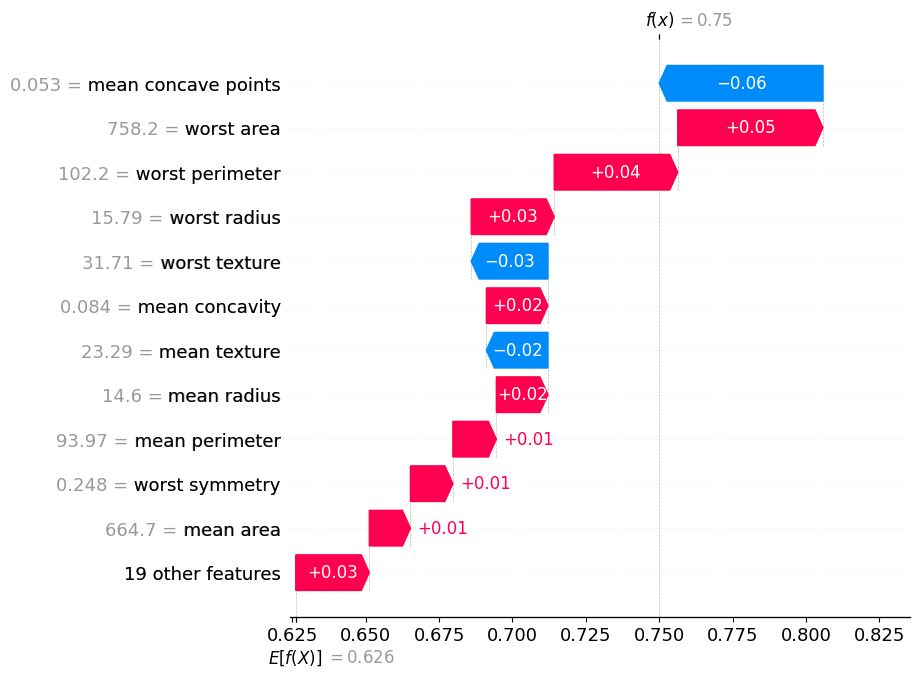

In [32]:
# Generate SHAP waterfall plot for the misclassified sample

mis_exp = explainer(X_test.iloc[[mis_idx]])

if len(mis_exp.values.shape) == 3:

    values = mis_exp.values[0, :, predicted_class]
    base_value = mis_exp.base_values[0, predicted_class]

else:

    values = mis_exp.values[0]
    base_value = mis_exp.base_values[0]

mis_waterfall = shap.Explanation(
    values=values,
    base_values=base_value,
    data=X_test.iloc[mis_idx].values,
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(
    mis_waterfall,
    max_display=12
)

plt.show()

### Task 16: Explain a Correctly Classified Sample

Select one correctly classified sample from the test dataset.

Generate a SHAP waterfall plot.

Compare this explanation with the misclassified sample from Task 15.

**Comment:**

Discuss how the feature contributions differ between the correctly classified and incorrectly classified samples.

---

In [33]:
# ============================================================
# TASK 16: EXPLAIN A CORRECTLY CLASSIFIED SAMPLE
# ============================================================

# Find correctly classified samples
correct_indices = np.where(
    y_test.values == y_pred
)[0]

print("Number of correctly classified samples:", len(correct_indices))
print("First few correctly classified indices:", correct_indices[:10])

Number of correctly classified samples: 137
First few correctly classified indices: [ 0  1  2  3  5  6  7  8  9 10]


In [34]:
# Select one correctly classified sample
correct_idx = correct_indices[0]

actual_class_correct = int(y_test.iloc[correct_idx])
predicted_class_correct = int(y_pred[correct_idx])

print("Selected correctly classified sample:", correct_idx)
print("Actual class:", data.target_names[actual_class_correct])
print("Predicted class:", data.target_names[predicted_class_correct])

print("\nPrediction probabilities:")
print(
    "Malignant:",
    model.predict_proba(X_test.iloc[[correct_idx]])[0][0]
)

print(
    "Benign   :",
    model.predict_proba(X_test.iloc[[correct_idx]])[0][1]
)

Selected correctly classified sample: 0
Actual class: benign
Predicted class: benign

Prediction probabilities:
Malignant: 0.0125
Benign   : 0.9875


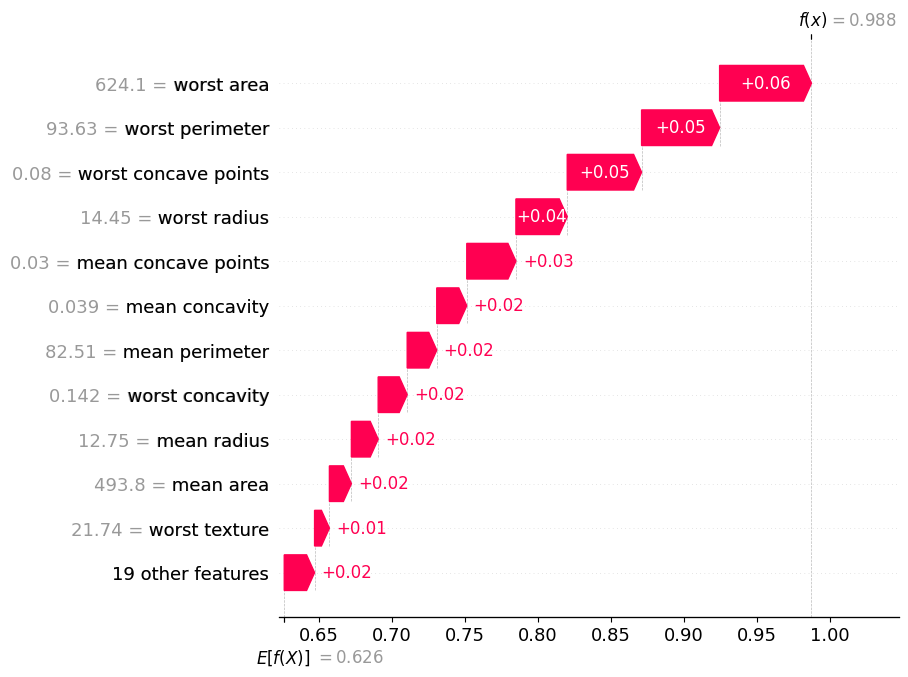

In [35]:
# Generate SHAP waterfall plot for correctly classified sample

correct_exp = explainer(X_test.iloc[[correct_idx]])

if len(correct_exp.values.shape) == 3:

    values = correct_exp.values[0, :, predicted_class_correct]
    base_value = correct_exp.base_values[
        0,
        predicted_class_correct
    ]

else:

    values = correct_exp.values[0]
    base_value = correct_exp.base_values[0]

correct_waterfall = shap.Explanation(
    values=values,
    base_values=base_value,
    data=X_test.iloc[correct_idx].values,
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(
    correct_waterfall,
    max_display=12
)

plt.show()

In [36]:
# Compare the correctly classified and misclassified samples

print("COMPARISON")
print("===========")

print("\nMisclassified Sample")
print("--------------------")
print("Index:", mis_idx)
print("Actual:", data.target_names[y_test.iloc[mis_idx]])
print("Predicted:", data.target_names[y_pred[mis_idx]])

print("\nCorrectly Classified Sample")
print("---------------------------")
print("Index:", correct_idx)
print("Actual:", data.target_names[y_test.iloc[correct_idx]])
print("Predicted:", data.target_names[y_pred[correct_idx]])

COMPARISON

Misclassified Sample
--------------------
Index: 4
Actual: malignant
Predicted: benign

Correctly Classified Sample
---------------------------
Index: 0
Actual: benign
Predicted: benign


### Final Observation

Write a short conclusion explaining how **SHAP provides both global and local explanations** of a trained machine learning model for breast cancer classification.

Your conclusion should discuss:

* Overall feature importance.
* Direction of feature effects.
* Individual feature contributions.
* Differences between individual tumour samples.
* Feature interactions.
* Correct and incorrect predictions.
* Global versus local explanations.
* The usefulness and limitations of SHAP for interpreting machine learning models.
* Why human/domain-expert validation is important when interpreting XAI results in healthcare.